In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.linear_model import Lasso, OrthogonalMatchingPursuit
from sklearn.decomposition import DictionaryLearning
from sklearn.preprocessing import StandardScaler


In [22]:
# ======================================================
# 1. LOAD DATA
# ======================================================

X_emb = np.load("./data/mnist_emb_model1.npy")  # (N, d)
X_emb = StandardScaler().fit_transform(X_emb)
X_emb = X_emb[:2000].T  # -> (d, N)

d, N = X_emb.shape
n_atoms = 256
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Data shape:", X_emb.shape)

Data shape: (128, 2000)


In [3]:
X_emb[0, :].mean()

np.float32(0.018429609)

In [4]:
# ======================================================
# 2. INITIAL DICTIONARY
# ======================================================

def normalize_columns(D):
    return D / (np.linalg.norm(D, axis=0, keepdims=True) + 1e-8)

D_init = normalize_columns(np.random.randn(d, n_atoms))

In [5]:
def compute_metrics(X, D, R, name=""):
    X_hat = D @ R  # (d, N)

    errors = (
        np.linalg.norm(X - X_hat, axis=0) /
        np.linalg.norm(X, axis=0)
    ) * 100

    sparsity = np.sum(np.abs(R) > 1e-4, axis=0)
    sparsity_ratio = np.mean(np.abs(R) > 1e-4)

    print(f"\n===== {name} =====")
    print(f"Avg error: {errors.mean():.4f}")
    print(f"Std error: {errors.std():.4f}")
    print(f"Avg sparsity: {sparsity.mean():.2f}")
    print(f"Sparsity ratio: {sparsity_ratio:.4f}")

    return errors, sparsity


In [6]:
import torch
import numpy as np
from utils import SingleUserADMMDict


# ----------------------------
# Synthetic data
# ----------------------------
np.random.seed(0)
torch.manual_seed(0)

d = X_emb.shape[0]
n = X_emb.shape[1]
K = int(X_emb.shape[0] * 3.0)
k_sparsity = int(d * 0.1)


# ----------------------------
# Train model
# ----------------------------
model = SingleUserADMMDict(
    d=d,
    K=K,
    k_sparsity=k_sparsity,
    rho=5,
    admm_iters=30
)

X_emb_tensor = torch.from_numpy(X_emb).float()


D_hat, S_hat, losses = model.fit(X_emb_tensor, outer_iters=100)


# ----------------------------
# Evaluation
# ----------------------------
print("\nFinal loss:", losses[-1])

print("\nSparsity check (active atoms):")
active = torch.sum(torch.norm(S_hat, dim=1) > 1e-6).item()
print("Active atoms:", active, "/", K)


torch.Size([128, 384]) torch.Size([128, 2000])
iter 0: loss=366.539307
torch.Size([128, 384]) torch.Size([128, 2000])
iter 1: loss=48.126644
torch.Size([128, 384]) torch.Size([128, 2000])
iter 2: loss=38.136490
torch.Size([128, 384]) torch.Size([128, 2000])
iter 3: loss=36.849434
torch.Size([128, 384]) torch.Size([128, 2000])
iter 4: loss=36.439434
torch.Size([128, 384]) torch.Size([128, 2000])
iter 5: loss=36.206329
torch.Size([128, 384]) torch.Size([128, 2000])
iter 6: loss=36.039795
torch.Size([128, 384]) torch.Size([128, 2000])
iter 7: loss=35.907288
torch.Size([128, 384]) torch.Size([128, 2000])
iter 8: loss=35.793858
torch.Size([128, 384]) torch.Size([128, 2000])
iter 9: loss=35.696091
torch.Size([128, 384]) torch.Size([128, 2000])
iter 10: loss=35.612843
torch.Size([128, 384]) torch.Size([128, 2000])
iter 11: loss=35.543015
torch.Size([128, 384]) torch.Size([128, 2000])
iter 12: loss=35.485977
torch.Size([128, 384]) torch.Size([128, 2000])
iter 13: loss=35.440338
torch.Size([128

In [7]:
print((D_hat.T @ D_hat).sum())
print(k_sparsity)

tensor(11.9599, device='cuda:0')
12


In [8]:

eps = 1e-4

row_nnz = torch.sum(torch.abs(S_hat) > eps, dim=1)
row_sparsity_ratio = row_nnz.float() / S_hat.shape[1]
print(torch.sum(row_nnz > 0))
print(torch.sum(row_sparsity_ratio))

tensor(12, device='cuda:0')
tensor(11.9985, device='cuda:0')


In [9]:

X_np = X_emb_tensor.detach().cpu().numpy()
D_np = D_hat.detach().cpu().numpy()
R_np = S_hat.detach().cpu().numpy()

errors, sparsity = compute_metrics(
    X_np,
    D_np,
    R_np,
    name="Admm"
)



===== Admm =====
Avg error: 7.1902
Std error: 1.8857
Avg sparsity: 12.00
Sparsity ratio: 0.0312


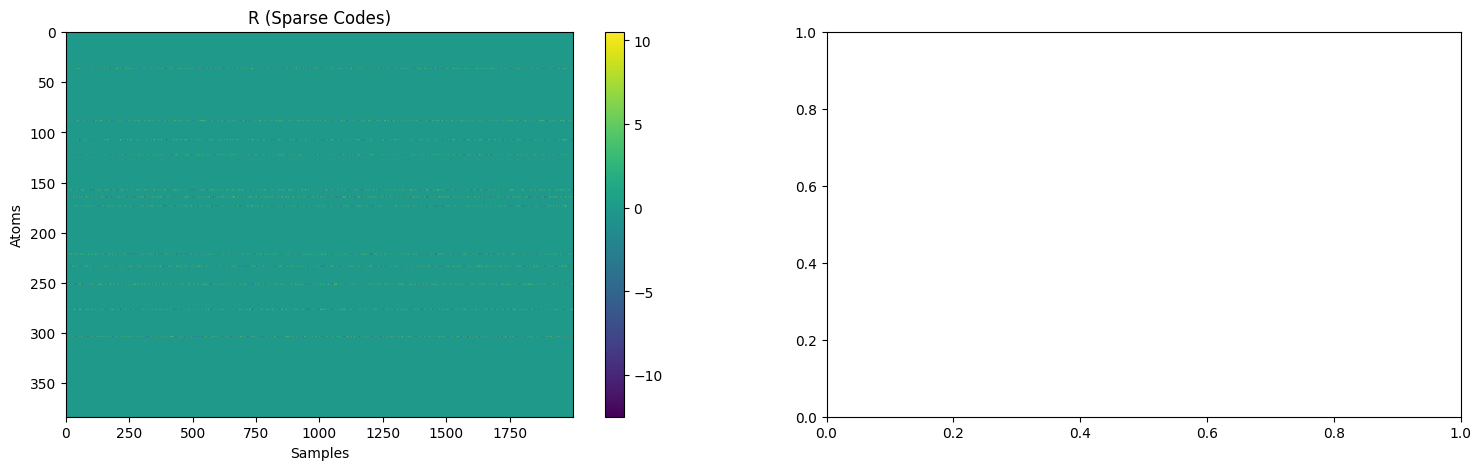

In [10]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Sparse codes
im0 = axes[0].imshow(R_np, aspect="auto", cmap="viridis")
axes[0].set_title("R (Sparse Codes)")
axes[0].set_xlabel("Samples")
axes[0].set_ylabel("Atoms")
plt.colorbar(im0, ax=axes[0])



In [23]:
data_dir = "./data/"
X1 = np.load(data_dir + "mnist_emb_model1.npy")
X2 = np.load(data_dir + "mnist_emb_model2.npy")
X3 = np.load(data_dir + "mnist_emb_model3.npy")


X_1 = StandardScaler().fit_transform(X1)
X_1 = X_1[:2000]  # -> (d, N)
X_2 = StandardScaler().fit_transform(X2)
X_2 = X_2[:2000]  # -> (d, N)
X_3 = StandardScaler().fit_transform(X3)
X_3 = X_3[:2000]  # -> (d, N)

d, N = X_1.shape
K = int(X_1.shape[0] * 3.0)
k_sparsity = int(d * 0.1)

print(f"d: {d}, N: {N}, K: {K}, k_sparsity: {k_sparsity}")
print("Data shape:", X_1.shape, X_2.shape, X_3.shape)



X_dict = {
    0: torch.tensor(X_1.T).float(),  # (d x n)
    1: torch.tensor(X_2.T).float(),
    2: torch.tensor(X_3.T).float()
}

d: 2000, N: 128, K: 6000, k_sparsity: 200
Data shape: (2000, 128) (2000, 128) (2000, 128)


In [12]:
from utils import MultiUserADMMDict

d = X1.shape[1]   # embedding dimension
K = int(X_emb.shape[0] * 2.0)           # number of atoms
k_sparsity = int(d * 0.9)   # number of active atoms

model = MultiUserADMMDict(
    d=d,
    K=n_atoms,
    k_sparsity=k_sparsity,
    rho=1.0,
    admm_iters=30
)

In [13]:
D, S_list, losses = model.fit(X_dict, outer_iters=100)

iter 0: loss=2568.560547
iter 1: loss=742.705566
iter 2: loss=390.787903
iter 3: loss=565.403198
iter 4: loss=219.061462
iter 5: loss=127.886642
iter 6: loss=88.662834
iter 7: loss=89.914429
iter 8: loss=86.408875
iter 9: loss=70.685448
iter 10: loss=64.442047
iter 11: loss=60.335533
iter 12: loss=84.578377
iter 13: loss=73.937515
iter 14: loss=60.857147
iter 15: loss=98.819458
iter 16: loss=78.468292
iter 17: loss=68.520309
iter 18: loss=73.072525
iter 19: loss=68.210281
iter 20: loss=62.283180
iter 21: loss=61.672642
iter 22: loss=55.814793
iter 23: loss=50.508198
iter 24: loss=48.009388
iter 25: loss=55.586868
iter 26: loss=46.119873
iter 27: loss=44.636215
iter 28: loss=43.781555
iter 29: loss=48.262768
iter 30: loss=44.699165
iter 31: loss=58.835739
iter 32: loss=51.313057
iter 33: loss=46.353493
iter 34: loss=60.641987
iter 35: loss=50.628899
iter 36: loss=55.597637
iter 37: loss=56.148438
iter 38: loss=60.171692
iter 39: loss=48.905396
iter 40: loss=44.840164
iter 41: loss=43.81

In [14]:
X_np = X_dict[2].detach().cpu().numpy()
D_np = D.detach().cpu().numpy()
R_np = S_list[2].detach().cpu().numpy()

errors, sparsity = compute_metrics(
    X_np,
    D_np,
    R_np,
    name="Admm"
)


===== Admm =====
Avg error: 0.5287
Std error: 0.1447
Avg sparsity: 114.99
Sparsity ratio: 0.4492


In [15]:

eps = 1e-4

row_nnz = torch.sum(torch.abs(S_list[2]) > eps, dim=1)
row_sparsity_ratio = row_nnz.float() / S_list[2].shape[1]
print(torch.sum(row_nnz > 0))
print(torch.sum(row_sparsity_ratio))

tensor(115, device='cuda:0')
tensor(114.9930, device='cuda:0')


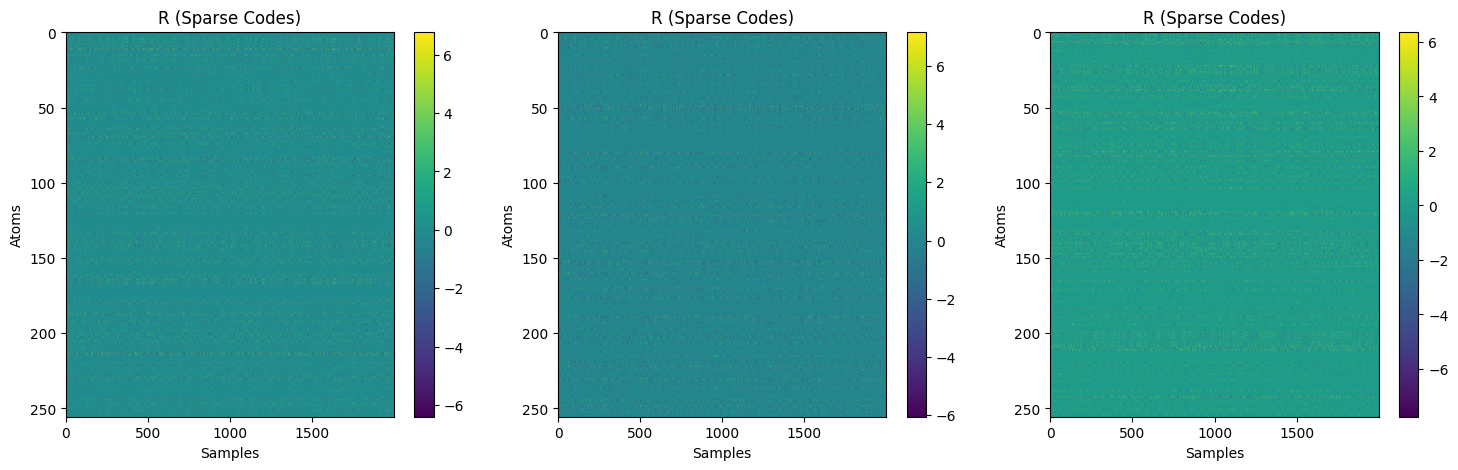

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sparse codes
im0 = axes[0].imshow(S_list[0].detach().cpu().numpy(), aspect="auto", cmap="viridis")
axes[0].set_title("R (Sparse Codes)")
axes[0].set_xlabel("Samples")
axes[0].set_ylabel("Atoms")
plt.colorbar(im0, ax=axes[0])

# Sparse codes
im1 = axes[1].imshow(S_list[1].detach().cpu().numpy(), aspect="auto", cmap="viridis")
axes[1].set_title("R (Sparse Codes)")
axes[1].set_xlabel("Samples")
axes[1].set_ylabel("Atoms")
plt.colorbar(im1, ax=axes[1])


# Sparse codes
im2 = axes[2].imshow(S_list[2].detach().cpu().numpy(), aspect="auto", cmap="viridis")
axes[2].set_title("R (Sparse Codes)")
axes[2].set_xlabel("Samples")
axes[2].set_ylabel("Atoms")
plt.colorbar(im2, ax=axes[2])

In [ ]:
from utils import MultiUserSheafDict

num_users = 3



# =========================================================
# DEFINE GRAPH
# =========================================================
edges = [
    (0, 1),
    (1, 2),
    (0, 2)
]

# =========================================================
# MODEL
# =========================================================
d, N = X_1.T.shape
print(d, N)
K = int(X_1.shape[0] * 3.0)
k_sparsity = int(d * 0.1)

model = MultiUserSheafDict(
    d=d,
    K=K,
    edges=edges,
    k_sparsity=k_sparsity,
    mu=0.01,
    rho=1.0,
    update_O_every=True
)

# =========================================================
# TRAIN
# =========================================================
D, S_list, O, losses = model.fit(X_dict, outer_iters=10)

# =========================================================
# EVALUATION
# =========================================================
print("\n===== FINAL EVALUATION =====")

recon_error = 0.0
sparsity = 0.0

for i, X_i in X_dict.items():
    X_i = X_i.to(device)
    S_i = S_list[i]

    recon = model.D @ S_i
    recon_error += torch.norm(X_i - recon).item()

    sparsity += torch.mean((S_i.abs() > 1e-6).float()).item()

print(f"Reconstruction error: {recon_error:.4f}")
print(f"Sparsity: {sparsity / num_users:.4f}")

# =========================================================
# CHECK O MATRICES
# =========================================================
for edge, O_uv in O.items():
    O_uv = O_uv.cpu()
    ortho_error = torch.norm(O_uv.T @ O_uv - torch.eye(d))
    print(f"Edge {edge}: Orthogonality error = {ortho_error:.6f}")

128 2000
torch.Size([128, 6000]) torch.Size([128, 2000])
torch.Size([128, 6000]) torch.Size([128, 2000])
torch.Size([128, 6000]) torch.Size([128, 2000])
Iter 0: Recon=389204.8125, Sheaf=196308.9219
torch.Size([128, 6000]) torch.Size([128, 2000])
torch.Size([128, 6000]) torch.Size([128, 2000])
torch.Size([128, 6000]) torch.Size([128, 2000])
Iter 1: Recon=11158.3398, Sheaf=1393963.0000
torch.Size([128, 6000]) torch.Size([128, 2000])
torch.Size([128, 6000]) torch.Size([128, 2000])
torch.Size([128, 6000]) torch.Size([128, 2000])
Iter 2: Recon=11254.9131, Sheaf=1408273.3750
torch.Size([128, 6000]) torch.Size([128, 2000])
torch.Size([128, 6000]) torch.Size([128, 2000])
torch.Size([128, 6000]) torch.Size([128, 2000])
Iter 3: Recon=11372.3809, Sheaf=1411482.1250
torch.Size([128, 6000]) torch.Size([128, 2000])
torch.Size([128, 6000]) torch.Size([128, 2000])
torch.Size([128, 6000]) torch.Size([128, 2000])
Iter 4: Recon=11367.0234, Sheaf=1415797.0000
torch.Size([128, 6000]) torch.Size([128, 2000]

In [27]:
X_np = X_dict[1].detach().cpu().numpy()
D_np = D.detach().cpu().numpy()
R_np = S_list[1].detach().cpu().numpy()

errors, sparsity = compute_metrics(
    X_np,
    D_np,
    R_np,
    name="Admm"
)


===== Admm =====
Avg error: 12.3710
Std error: 1.2814
Avg sparsity: 10.00
Sparsity ratio: 0.0017
